# **Avaliação e classificação da qualidade de vinhos**


### **Contexto**
A qualidade do vinho é um atributo complexo, influenciado por diferentes fatores fisico-quimicos. Parametros como acidez fixa e volatil, acido citrico, acucar residual, cloretos, dioxido de enxofre (livre e total), densidade, pH, sulfatos e teor alcoolico contribuem para as caracteristicas sensoriais que determinam a nota final.

### **Objetivo geral**
Desenvolver um modelo de Random Forest para classificacao multiclasse da qualidade de vinhos, utilizando as variaveis fisico-quimicas da base para prever a pontuacao de qualidade.

### **Base de dados**
#### **Caracteristicas dos vinhos (features)**

| Feature               | Descricao                                                                 |
|-----------------------|---------------------------------------------------------------------------|
| Fixed Acidity         | Acidez fixa do vinho.                                                     |
| Volatile Acidity      | Acidez volatil do vinho.                                                  |
| Citric Acid           | Quantidade de acido citrico no vinho.                                     |
| Residual Sugar        | Acucar residual presente no vinho.                                        |
| Chlorides             | Nivel de cloretos no vinho.                                               |
| Free Sulfur Dioxide   | Dioxido de enxofre livre no vinho.                                        |
| Total Sulfur Dioxide  | Quantidade total de dioxido de enxofre no vinho.                          |
| Density               | Densidade do vinho.                                                       |
| pH                    | Nivel de pH do vinho.                                                     |
| Sulphates             | Quantidade de sulfatos no vinho.                                          |
| Alcohol               | Teor alcoolico do vinho.                                                  |
| Quality               | Pontuacao do vinho com base em avaliacao sensorial (escala de 0 a 10).   |

Observacao: este estudo considera `quality` como variavel alvo para classificacao multiclasse.

### **1. Importação de bibliotecas e análise exploratória dos dados**

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import randint, uniform

from sklearn.model_selection import StratifiedKFold

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from sklearn.metrics import cohen_kappa_score, make_scorer

warnings.filterwarnings("ignore", category=FutureWarning)

# Carregando os dados
df = pd.read_csv("../../Base de Dados/winequality-red.csv", delimiter=',')
display(df)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [2]:
resume=pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Mínimo': df.min(),
    'Máximo': df.max()      
})
print(resume)

                         Tipo  Nulos   Mínimo     Máximo
fixed acidity         float64      0  4.60000   15.90000
volatile acidity      float64      0  0.12000    1.58000
citric acid           float64      0  0.00000    1.00000
residual sugar        float64      0  0.90000   15.50000
chlorides             float64      0  0.01200    0.61100
free sulfur dioxide   float64      0  1.00000   72.00000
total sulfur dioxide  float64      0  6.00000  289.00000
density               float64      0  0.99007    1.00369
pH                    float64      0  2.74000    4.01000
sulphates             float64      0  0.33000    2.00000
alcohol               float64      0  8.40000   14.90000
quality                 int64      0  3.00000    8.00000


O conjunto de dados possui 1.599 linhas e 12 colunas. São 11 variáveis explicativas numéricas (`float64`) e uma variável alvo (`quality`) inteira. Não há valores ausentes.

---

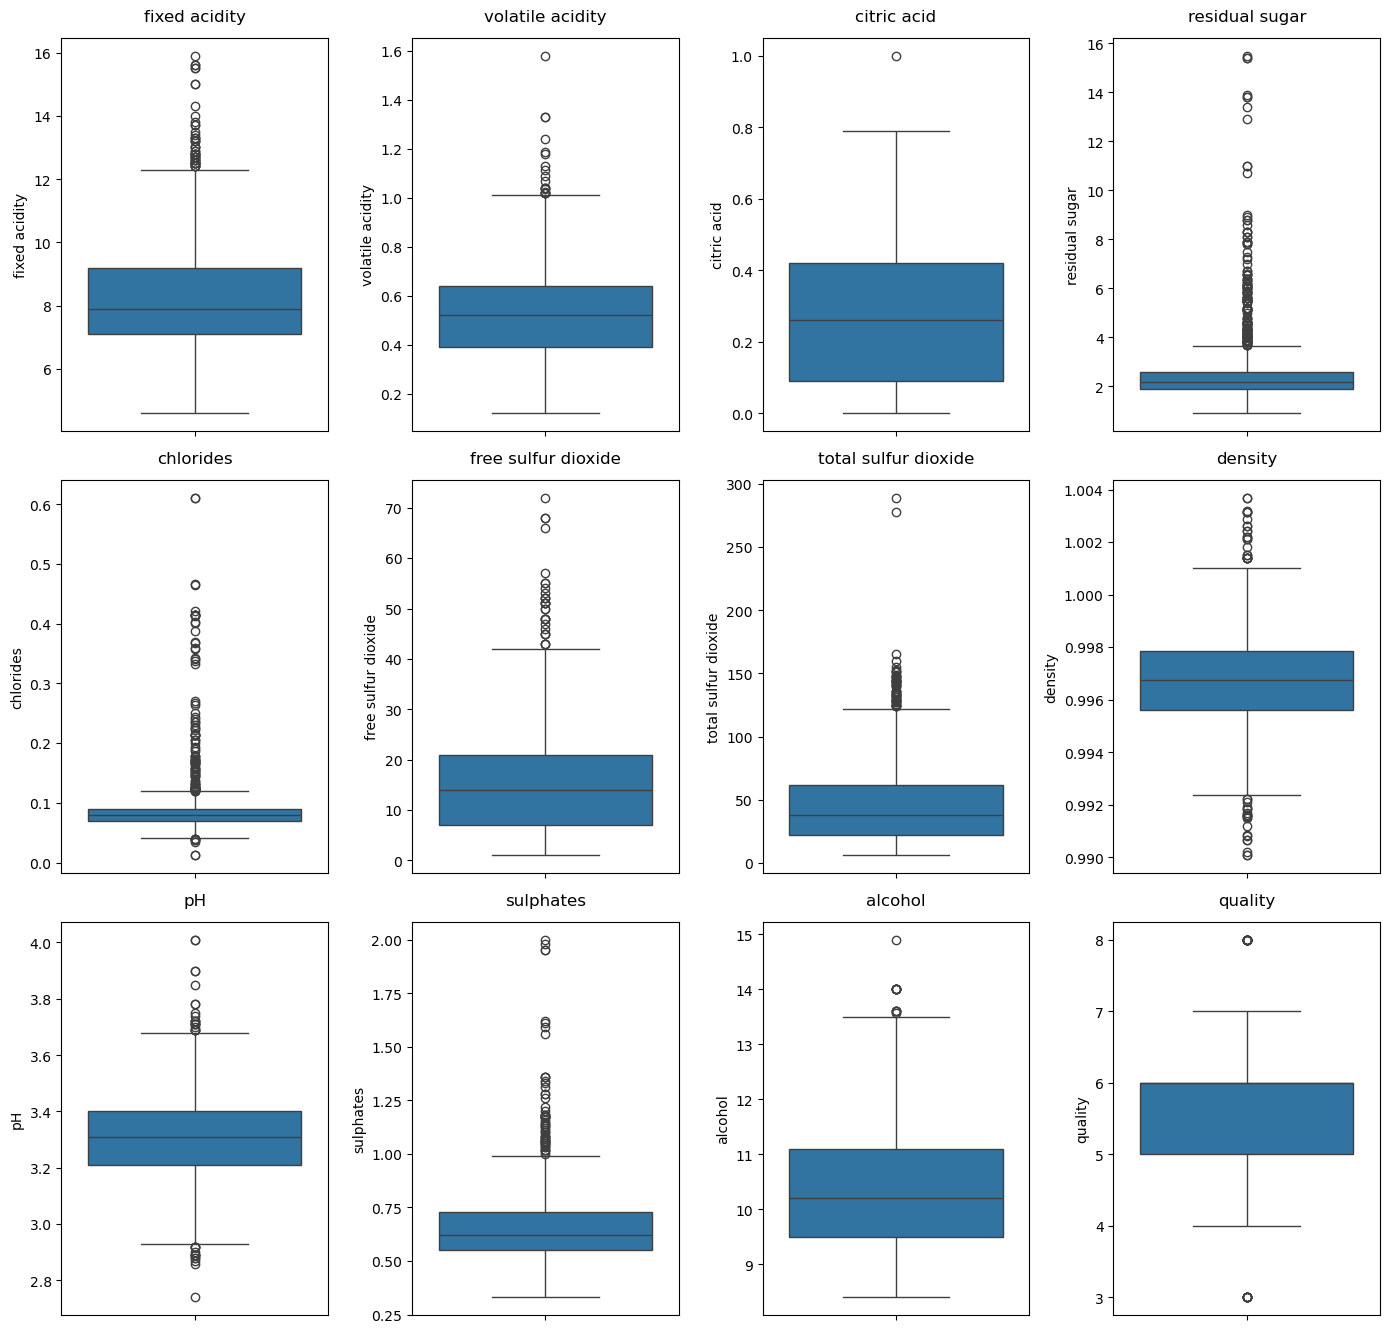

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
def plot_boxplots_grid(dataframe, columns, nrows=3, ncols=4, figsize=(14, 14)):
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = np.array(axs).reshape(nrows, ncols)

    for idx, feature in enumerate(columns):
        row, col = divmod(idx, ncols)

        plot_args = {'data': dataframe[feature], 'ax': axs[row, col]}

        sns.boxplot(**plot_args)
        axs[row, col].set_title(feature, pad=12)

    # Oculta eixos excedentes caso o numero de variaveis seja menor que a grade.
    for idx in range(len(columns), nrows * ncols):
        axs.flat[idx].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


boxplot_columns = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
 ]

plot_boxplots_grid(df, boxplot_columns)
df.describe()

Sobre outliers: a analise do intervalo interquartil e dos boxplots indica valores extremos em algumas variaveis, principalmente `residual sugar`, `chlorides` e `total sulfur dioxide`. Como os dados nao apresentaram normalidade no teste de Shapiro-Wilk (ver anexo), foi adotado o limiar de `4.5 * IQR` para remover apenas outliers mais extremos.


### **2. Pré-processamento dos dados**

In [4]:
# filtragem via interquartil (Limar 4.5*IQR) -- priorizar remoção de outliers extremos
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR = Q3 - Q1
df2 = df[~((df < Q1-4.5*IQR) | (df > Q3+4.5*IQR)).any(axis=1)]

percentual_removido = (1 - len(df2) / len(df)) * 100
print("\nDescribes Sem Outliers",f"(Percentual removido: {percentual_removido:.2f}%)")
display(df2.describe())


Describes Sem Outliers (Percentual removido: 6.50%)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000
mean,8.306957,0.528134,0.262415,2.332876,0.080813,15.635786,45.213378,0.996663,3.318448,0.645224,10.440301,5.638127
std,1.746361,0.180308,0.191273,0.731143,0.019599,9.949300,30.938407,0.001839,0.151964,0.138809,1.052984,0.801282
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.860000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995540,3.220000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.320000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.500000,0.089000,21.000000,60.000000,0.997800,3.410000,0.720000,11.100000,6.000000
max,15.600000,1.580000,0.790000,5.700000,0.178000,57.000000,165.000000,1.003200,4.010000,1.360000,14.000000,8.000000


Principais mudancas apos remocao de outliers:

- O desvio padrao diminuiu em todas as variaveis, indicando menor dispersao.
- Os valores maximos reduziram de forma relevante, especialmente em `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide`.
- Medias e medianas mudaram pouco, sugerindo baixo impacto dos outliers no centro da distribuicao.
- A amplitude geral foi reduzida, deixando os dados mais homogeneos.

Em resumo, a base ficou mais consistente e menos sensivel a valores extremos, o que tende a beneficiar as etapas de modelagem.


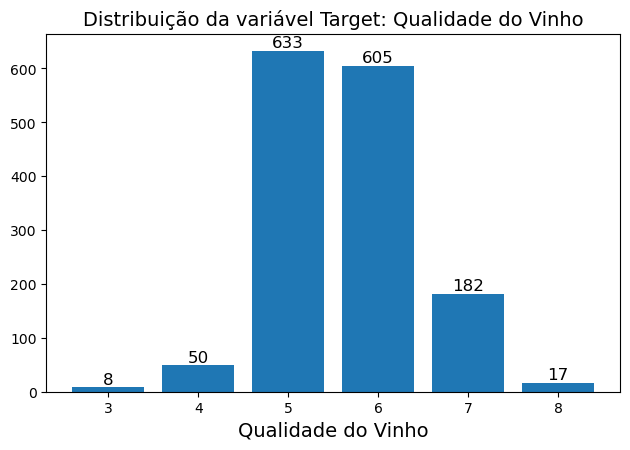

|   quality |   Contagem |   Percentual (%) |
|----------:|-----------:|-----------------:|
|         3 |          8 |             0.54 |
|         4 |         50 |             3.34 |
|         5 |        633 |            42.34 |
|         6 |        605 |            40.47 |
|         7 |        182 |            12.17 |
|         8 |         17 |             1.14 |


In [ ]:
# distribuição da variável target: quality
c=df2['quality'].value_counts().sort_index() 
p= df2['quality'].value_counts(normalize=True).sort_index() * 100

plt.bar(c.index, c.values)
plt.title('Distribuição da variável Target: Qualidade do Vinho', fontsize=14)
plt.xlabel('Qualidade do Vinho',fontsize=14)

for i in range(len(c)):
    plt.text(c.index[i], c.values[i] , f'{c.values[i]}', ha='center', va='bottom', fontsize=12)    
plt.tight_layout(rect=[0.0, 0, 1, 0.96])
plt.show()


resumo = pd.DataFrame({
    'Contagem': c,
    'Percentual (%)': p.round(2)
})
print(resumo)

Balanceamento da variavel alvo:
A distribuicao da variavel `quality` e desbalanceada. As classes 5 e 6 representam aproximadamente 82,81% da base, enquanto as classes 3, 4 e 8 juntas representam cerca de 5%. Esse desequilibrio afeta a capacidade do modelo de aprender classes minoritarias.


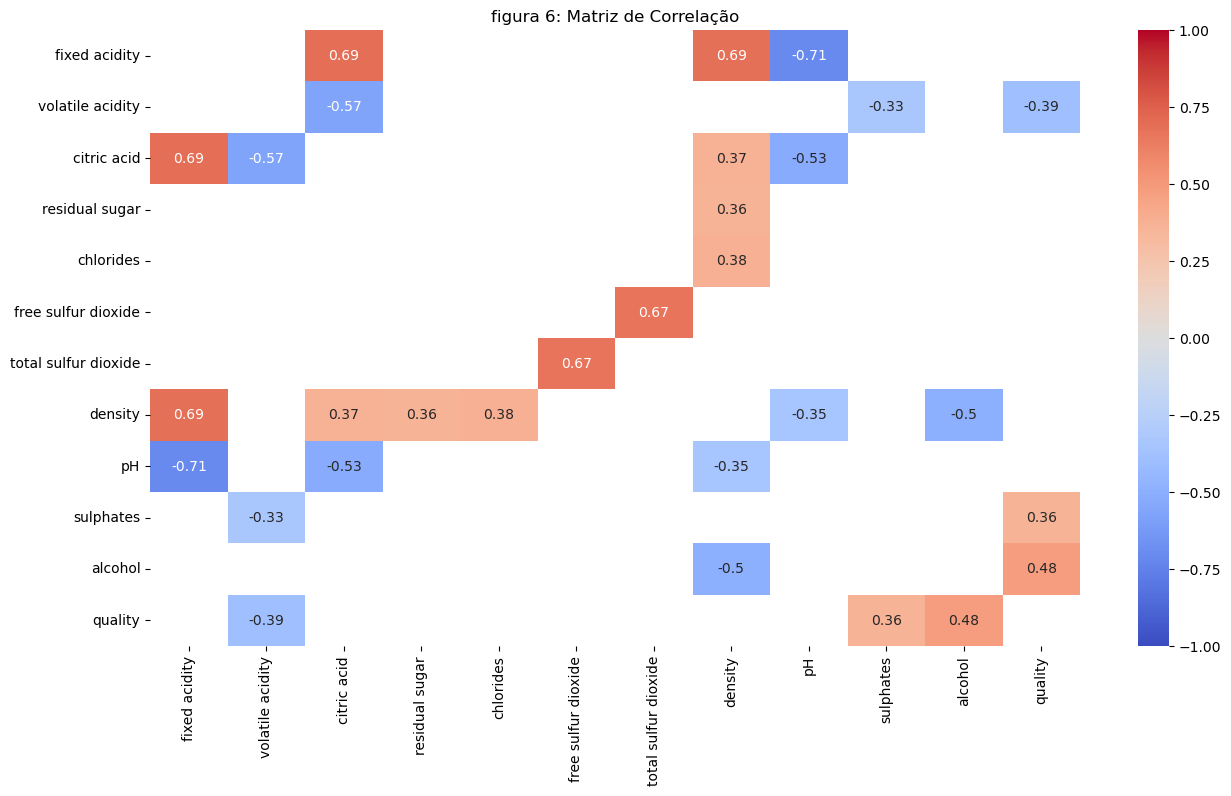

In [ ]:
correlation_matrix = df2.corr()
# Exibir apenas valores >|0.15| & ignorar correlaca 1.
dfcm=correlation_matrix
dfcm[(dfcm < 0.3)&(dfcm > -0.3)] = pd.NA
dfcm[dfcm >=0.99] = pd.NA

plt.figure(figsize=(15, 8))
sns.heatmap(dfcm, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('figura 6: Matriz de Correlação')

plt.show()

# Atribuição de novo dataframe com variaveis mais correlacionadas com a qualidade do vinho(target)
df3=df2[['alcohol','sulphates','volatile acidity','density','citric acid']]

Correlacao com a qualidade do vinho:
As correlacoes mais relevantes com `quality` foram observadas para `alcohol` (0.4804), `sulphates` (0.3613) e `volatile acidity` (-0.3941). Tambem ha relacoes indiretas envolvendo `density` e `citric acid`, associadas a `alcohol` e `volatile acidity`.

---

### **3. Preparação Final dos Dados**
#### 3.1 Definição de features(x) e target(y)

In [7]:
# Separação da variável target e das variáveis independentes
x = df3                     # Features (variáveis independentes)
y = df2['quality']          # Target (variável dependente)

#### 3.2 Divisão Treino x Teste

In [8]:
#Separação das bases de treino e test.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33,random_state=33)

print(f"Base de Treino (feat):    {x_train.shape}")
print(f"Base de Treino (tag ): {y_train.shape}")
print(f"Base de Teste  (feat): {x_test.shape}")
print(f"Base de Teste  (tag ): {y_test.shape}")

print(y_test.value_counts().sort_index())


Base de Treino (feat):    (1001, 5)
Base de Treino (tag ): (1001,)
Base de Teste  (feat): (494, 5)
Base de Teste  (tag ): (494,)
quality
3      6
4     25
5    207
6    191
7     61
8      4
Name: count, dtype: int64


### **4. Modelagem base - Random Forest**
#### 4.1 Inicializacao e treino

In [9]:
rf_model = RandomForestClassifier(random_state=33)

#treinamento dos modelos
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=33)

#### 4.2 Teste Modelo

In [10]:
# Aplicação do modelo na base de teste
y_pred = rf_model.predict(x_test)

### **5. Avaliacao**
#### 5.1 Metricas avaliadas: acuracia, precision, recall, F1-score e matriz de confusao


Resultado Modelo Base
Acuracia do Modelo: 0.62
Relatorio de Classificacao:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        25
           5       0.65      0.77      0.71       207
           6       0.58      0.59      0.58       191
           7       0.65      0.54      0.59        61
           8       0.00      0.00      0.00         4

    accuracy                           0.62       494
   macro avg       0.31      0.32      0.31       494
weighted avg       0.58      0.62      0.59       494

Matriz de Confusao:
[[  0   0   4   2   0   0]
 [  0   0  17   8   0   0]
 [  0   0 160  46   1   0]
 [  0   0  63 113  15   0]
 [  0   0   2  25  33   1]
 [  0   0   0   2   2   0]]


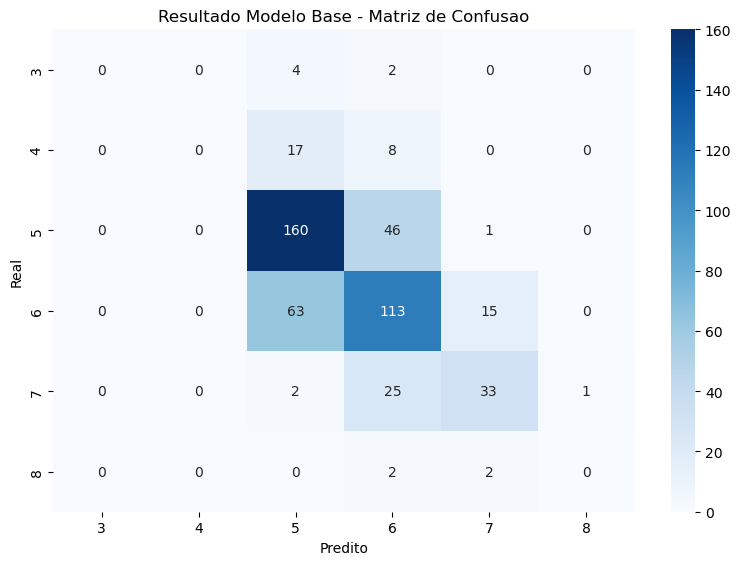

In [11]:
def report_classification_results(y_true, y_pred, labels, title):
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    classification_rep = classification_report(y_true, y_pred, zero_division=0)

    print('=' * 60)
    print(title)
    print('=' * 60)
    print(f'Acuracia do Modelo: {accuracy:.2f}')
    print('Relatorio de Classificacao:')
    print(classification_rep)
    print('=' * 60)
    print('Matriz de Confusao:')
    print(conf_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f'{title} - Matriz de Confusao')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout(rect=[0.0, 0, 1, 0.96])
    plt.show()

    return {
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': classification_rep
    }


baseline_results = report_classification_results(
    y_true=y_test,
    y_pred=y_pred,
    labels=sorted(y.unique()),
    title='Resultado Modelo Base'
 )

#### 5.2 Comentarios e insights

Acuracia do modelo base (`0.62`): o modelo acerta 62% dos casos, mas essa metrica e influenciada pelas classes majoritarias.

Media macro (`0.31`): `precision`, `recall` e `F1-score` baixos indicam dificuldade nas classes minoritarias.

Media ponderada (`0.58`, `0.62`, `0.59`): o desempenho se aproxima da acuracia geral devido ao peso das classes 5 e 6.

Matriz de confusao: os principais acertos estao nas classes 5 e 6. As classes 3, 4 e 8 nao foram previstas corretamente, reforcando o efeito do desbalanceamento.

Conclusao parcial: para melhorar o desempenho nas classes raras, e necessario adotar estrategias de balanceamento e ajustes de modelagem direcionados.


### **6. Otimizacao de hiperparametros - Randomized Search**

Nesta etapa, sao comparadas duas estrategias de melhoria do Random Forest:
- Tentativa 1 (T1): ajuste com `class_weight`.
- Tentativa 2 (T2): treino com base balanceada via oversampling.

#### Tentativa 1 (T1): `class_weight`
##### Grid de busca e Randomized Search

In [12]:
param_grid = {
    'n_estimators': [200,400,1000],
    'max_depth': [None,10,20,40,80],
    'min_samples_split': randint(2,11),
    'min_samples_leaf': randint(1,6),
    'class_weight': [{3:30, 4:8,7:4,8:50}],
    'max_features': uniform(0.3, 0.7),
    'bootstrap'   : [True, False],
    'criterion'   : ["gini", "entropy", "log_loss"]
}
kappa_scorer = make_scorer(cohen_kappa_score)

cv_fold = StratifiedKFold(
    n_splits=4,          # máximo seguro dado o tamanho da menor classe
    shuffle=True,        # embaralha antes de dividir
    random_state=33
)


random_search_a = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=200, 
    cv=cv_fold , 
    n_jobs=-1,
    verbose=0, 
    random_state=33, 
    scoring=kappa_scorer)

random_search_a.fit(x_train, y_train)
random_search_a.best_estimator_

print(f"Melhores Hiperparâmetros: {random_search_a.best_params_}")

/home/ramon/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=4.
  warnings.warn(


Melhores Hiperparâmetros: {'bootstrap': False, 'class_weight': {3: 30, 4: 8, 7: 4, 8: 50}, 'criterion': 'gini', 'max_depth': 40, 'max_features': np.float64(0.3221954260701241), 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


#### Tentativa 2 (T2): base de treino balanceada
##### Grid de busca e Randomized Search

In [13]:

param_grid = {
    'n_estimators': [400],
    'max_depth': [20,40],
    'min_samples_split': randint(2,11),
    'min_samples_leaf': [1],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'max_features': ['sqrt', 'log2'],
    'bootstrap'   : [True, False],
    'criterion'   : ["gini", "entropy", "log_loss"]
}


ros= RandomOverSampler(random_state=33)
x_train_b, y_train_b = ros.fit_resample(x_train, y_train)


random_search_b = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=200, 
    cv=cv_fold , 
    n_jobs=-1,
    verbose=0, 
    random_state=33, 
    scoring=kappa_scorer)

random_search_b.fit(x_train_b, y_train_b)
random_search_b.best_estimator_
print(f"Melhores Hiperparâmetros: {random_search_b.best_params_}")



Melhores Hiperparâmetros: {'bootstrap': False, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 400}


#### 6.1 Resultado dos modelos com hiperparametros otimizados

Resultado Tentativa 1
Acuracia do Modelo: 0.65
Relatorio de Classificacao:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        25
           5       0.69      0.83      0.75       207
           6       0.61      0.62      0.61       191
           7       0.65      0.49      0.56        61
           8       0.00      0.00      0.00         4

    accuracy                           0.65       494
   macro avg       0.33      0.32      0.32       494
weighted avg       0.61      0.65      0.62       494

Matriz de Confusao:
[[  0   0   5   1   0   0]
 [  0   0  16   9   0   0]
 [  0   0 172  34   1   0]
 [  0   2  56 118  15   0]
 [  0   0   0  28  30   3]
 [  0   0   0   4   0   0]]


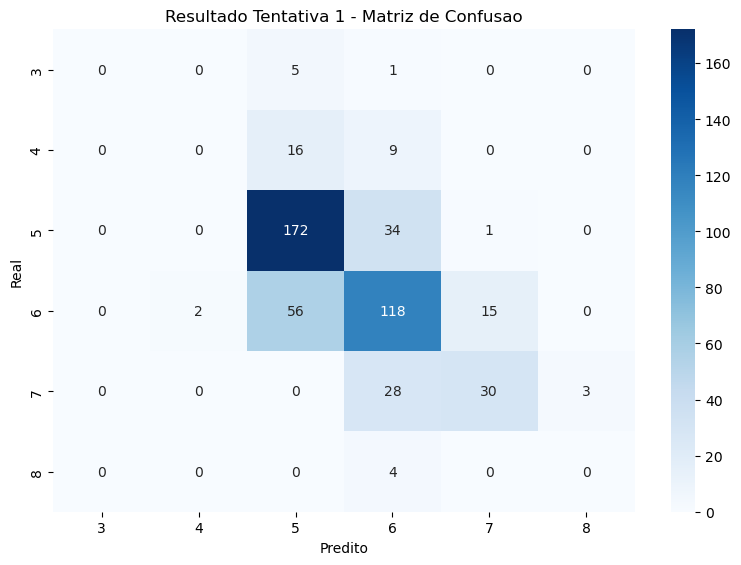

In [14]:
best_rf_model = random_search_a.best_estimator_

best_rf_model.fit(x_train, y_train)
y_pred2 = best_rf_model.predict(x_test)

t1_results = report_classification_results(
    y_true=y_test,
    y_pred=y_pred2,
    labels=sorted(y.unique()),
    title='Resultado Tentativa 1'
 )

Resultado Tentativa 2
Acuracia do Modelo: 0.63
Relatorio de Classificacao:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        25
           5       0.68      0.80      0.73       207
           6       0.59      0.59      0.59       191
           7       0.62      0.56      0.59        61
           8       0.00      0.00      0.00         4

    accuracy                           0.63       494
   macro avg       0.31      0.32      0.32       494
weighted avg       0.59      0.63      0.61       494

Matriz de Confusao:
[[  0   0   4   2   0   0]
 [  0   0  15  10   0   0]
 [  0   0 165  38   4   0]
 [  0   2  58 112  17   2]
 [  0   1   0  24  34   2]
 [  0   0   0   4   0   0]]


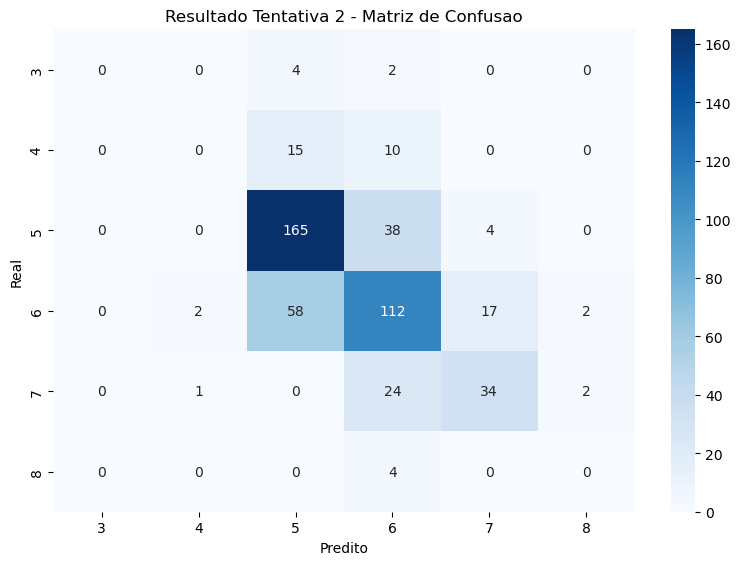

In [15]:
best_rf_model = random_search_b.best_estimator_

best_rf_model.fit(x_train_b, y_train_b)
y_pred3 = best_rf_model.predict(x_test)

t2_results = report_classification_results(
    y_true=y_test,
    y_pred=y_pred3,
    labels=sorted(y.unique()),
    title='Resultado Tentativa 2'
 )

#### 6.2 Discussao e comparacao dos resultados

Com base nas modelagens, os modelos foram comparados por acuracia, metricas por classe e matriz de confusao.

#### Visao geral

| Modelo  | Estrategia                                    | Acuracia | F1 (ponderado) | Kappa | Observacoes principais |
|---------|-----------------------------------------------|----------|----------------|-------|------------------------|
| Default | Random Forest padrao                          | 0.62     | 0.59           | 0.46  | Melhor nas classes majoritarias. |
| T1      | Randomized Search + `class_weight` customizado| 0.65     | 0.62           | 0.50  | Melhor desempenho geral entre os modelos. |
| T2      | Randomized Search + `RandomOverSampler`       | 0.63     | 0.61           | 0.48  | Ganho discreto em relacao ao modelo base. |

#### Comparacao entre modelos

- T1 vs Default: houve ganho de 3 pontos percentuais em acuracia (`0.65` vs `0.62`) e melhora nas classes majoritarias, especialmente na classe 5.
- T2 vs Default: apresentou melhoria pequena (`0.63` vs `0.62`), sem avancos consistentes nas classes raras.
- T1 vs T2: T1 teve melhor resultado global; T2 mostrou comportamento competitivo em alguns cenarios, mas com menor estabilidade geral.

#### Pontos de melhoria

- O `class_weight` customizado da T1 foi a estrategia mais eficiente neste experimento.
- O oversampling isolado (T2) nao trouxe ganho suficiente para justificar o custo computacional adicional.
- As classes 3, 4 e 8 continuam com desempenho fraco; sao necessarias estrategias especificas para classes raras.

#### Conclusao da etapa

A T1 (`class_weight` + Randomized Search) apresentou o melhor equilibrio entre desempenho e robustez. Para iteracoes futuras, recomenda-se explorar tecnicas adicionais para desbalanceamento (por exemplo, ajustes de limiar, ensembles focados em classes raras e modelos alternativos como Gradient Boosting/XGBoost).


### **7. Comentarios finais**

A modelagem apresentou evolucao, mas ainda ha espaco para melhorias com tecnicas mais robustas para desbalanceamento. Alem disso, o estudo usou apenas 5 das 11 variaveis disponiveis, o que pode limitar a capacidade preditiva. Em etapas futuras, vale testar novas combinacoes de features, modelos alternativos e ate uma abordagem de regressao com arredondamento para classes.